# Distance-based contacts at entrenched sites

The solvent accessibility analysis (`solvent_accessibility_analysis.ipynb`) measures how much the antigen, light chain, and CDR-H3 (sites 95–102) bury each heavy-chain residue as a change in relative solvent accessibility (ΔRSA).
Here we ask whether the same picture holds when contact is measured directly from atomic coordinates instead:

- **minimum heavy-atom distance** between the residue and each partner, and
- **number of partner heavy atoms within 5 Å** of the residue.

## Input data

- `_output/sasa_human_chothia_anarci.csv(.gz)`: per-residue RSA and ΔRSA from `run_sasa_analysis.py`.
- `_output/contacts_human_chothia.csv`: per-residue distances and contact counts from `run_contact_analysis.py`, computed on the same filtered structures and chain assignments:

      python run_contact_analysis.py --scheme opig-chothia --organism "homo sapiens" --output _output/contacts_human_chothia.csv

For the CDR-H3 partner, residues within two positions in chain order of a CDR-H3 residue are excluded from the partner set, so covalently bonded neighbours (e.g. site 94) do not count as trivial contacts; sites 95–102 themselves have no CDR-H3 value, as in the ΔRSA analysis.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

from utils import is_in_cdr, sort_antibody_sites, GERMLINE_PATH_DICTIONARY, load_entrenched_sites
from sasa_plotting import (
    _prepare_entrenchment_data,
    _plot_entrenchment_boxplot,
    _add_entrenchment_legend,
)

numbering_scheme = 'chothia'
CONTACT_CUTOFF = 5.0  # Å, must match run_contact_analysis.py
MIN_STRUCTURES = 30  # minimum structures per (family, site) in the agreement tables
PARTNERS = {
    'antigen': 'burial_by_antigen',
    'light': 'burial_by_light_chain',
    'cdr3': 'burial_by_vdj_junction',
}
PARTNER_LABELS = {'antigen': 'Antigen', 'light': 'Light Chain', 'cdr3': 'CDR3'}

## Load RSA data (same preprocessing as the solvent accessibility notebook)

In [2]:
path = '_output/sasa_human_chothia_anarci.csv'
if not os.path.exists(path):
    path = path + '.gz'
df = pd.read_csv(path, dtype={'site': str})

df = df[(df.chain_id == df.heavy_chain_id) & (df.organism == 'homo sapiens')]
df = df[(df.residue_number <= 129) & (df.residue_number > 0)]
df['is_cdr'] = df.site.apply(is_in_cdr, numbering_scheme=numbering_scheme)

# Germline annotation: exact allele match, falling back to the *01 allele of the same gene
germline = pd.read_csv(GERMLINE_PATH_DICTIONARY[numbering_scheme], dtype={'site': str})
germline = germline.rename(columns={'v_gene': 'v_gene_heavy', 'amino_acid': 'germline_amino_acid',
                                    'v_family': 'v_family_heavy'}).drop(columns=['codon'])
merged = pd.merge(df, germline, on=['v_gene_heavy', 'site'], how='left', indicator=True)
unmatched_mask = merged['_merge'] == 'left_only'
unmatched = merged[unmatched_mask].drop(columns=['germline_amino_acid', 'v_family_heavy', '_merge'])
unmatched['v_gene_base'] = unmatched['v_gene_heavy'].str.replace(r'\*\d+$', '', regex=True)
germline_01 = germline[germline['v_gene_heavy'].str.endswith('*01')].copy()
germline_01['v_gene_base'] = germline_01['v_gene_heavy'].str.replace(r'\*\d+$', '', regex=True)
unmatched = pd.merge(unmatched, germline_01.drop(columns=['v_gene_heavy']),
                     on=['v_gene_base', 'site'], how='inner').drop(columns=['v_gene_base'])
df = pd.concat([merged[~unmatched_mask].drop(columns=['_merge']), unmatched], ignore_index=True)
df = df.dropna(subset=['germline_amino_acid'])
df['is_germline'] = df['amino_acid'] == df['germline_amino_acid']
df['v_family_heavy'] = df.v_gene_heavy.str.extract(r'(IGHV\d+)', expand=False)

# Positive = burial by the partner
for effect, name in [('rsa_antigen_effect', 'burial_by_antigen'),
                     ('rsa_light_effect', 'burial_by_light_chain'),
                     ('rsa_vdj_junction_effect', 'burial_by_vdj_junction')]:
    df[name] = -df[effect]

print('Structures:', df.pdb_id.nunique())

Structures: 2229


## Merge distance-based contacts

In [3]:
contacts = pd.read_csv('_output/contacts_human_chothia.csv', keep_default_na=False, na_values=[''])
contacts['insertion_code'] = contacts['insertion_code'].fillna('')
df['insertion_code'] = df['insertion_code'].fillna('')
df['residue_number'] = df['residue_number'].astype(int)

keys = ['pdb_id', 'chain_id', 'residue_number', 'insertion_code']
n_before = len(df)
df = pd.merge(df, contacts.rename(columns={'amino_acid': 'amino_acid_contacts'}), on=keys, how='inner')
print(f'Rows matched: {len(df)} of {n_before} ({len(df) / n_before:.1%})')

mismatch = (df.amino_acid != df.amino_acid_contacts).sum()
if mismatch:
    raise ValueError(f'{mismatch} rows have different amino acids in the RSA and contact tables')

for partner, burial_col in PARTNERS.items():
    df[f'contact_{partner}'] = (df[f'min_dist_{partner}'] < CONTACT_CUTOFF).astype(float)
    df[f'buried_{partner}'] = (df[burial_col] > 0).astype(float)
    # CDR3 sites (95-102) have no CDR3 value in either analysis
    missing = df[f'min_dist_{partner}'].isna() | df[burial_col].isna()
    df.loc[missing, [f'contact_{partner}', f'buried_{partner}']] = np.nan

df_germ = df[df.is_germline == True]
print('Germline-encoded structures per family:')
print(df_germ.groupby('v_family_heavy').pdb_id.nunique().loc[['IGHV1', 'IGHV3']])

Rows matched: 212486 of 217354 (97.8%)
Germline-encoded structures per family:
v_family_heavy
IGHV1     727
IGHV3    1013
Name: pdb_id, dtype: int64


In [4]:
_, _, _, _, within_dfs, _ = load_entrenched_sites(numbering_scheme)
entrenched = {vfam: set(within_dfs[within_dfs.v_family == vfam]['site'].astype(str))
              for vfam in ['IGHV1', 'IGHV3']}
entrenched

{'IGHV1': {'33', '50', '52'}, 'IGHV3': {'33', '35', '50', '52', '53'}}

## Per-site distances and contact counts at within-family entrenched sites

In [5]:
def plot_contacts_by_entrenchment(df, v_family, entrenched_site_set, metrics, ylim,
                                  ref_line=None, save_path=None, figsize=(20, 9)):
    filtered, sorted_sites, site_colors, entrenched_for_vfam = _prepare_entrenchment_data(
        df, v_family, entrenched_site_set, germline_only=True, entrenched_site_colors=None
    )
    fig, axes = plt.subplots(len(metrics), 1, figsize=figsize, sharex=True)
    for ax, (y_var, y_label) in zip(axes, metrics):
        _plot_entrenchment_boxplot(ax, filtered, sorted_sites, site_colors, y_var, y_label,
                                   entrenched_for_vfam, numbering_scheme)
        ax.set_ylim(*ylim)
        if ref_line is not None:
            ax.axhline(ref_line, color='black', linestyle='--', linewidth=1)
    axes[-1].set_xlabel('Site', fontsize=14)
    _add_entrenchment_legend(fig, sorted_sites, site_colors, entrenched_for_vfam, position='bottom')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
    return fig, axes


distance_metrics = [(f'min_dist_{p}', f'Min distance to {PARTNER_LABELS[p]} (Å)') for p in PARTNERS]
count_metrics = [(f'n_atoms_5A_{p}', f'{PARTNER_LABELS[p]} atoms within 5 Å') for p in PARTNERS]

### Minimum heavy-atom distance (dashed line: 5 Å)

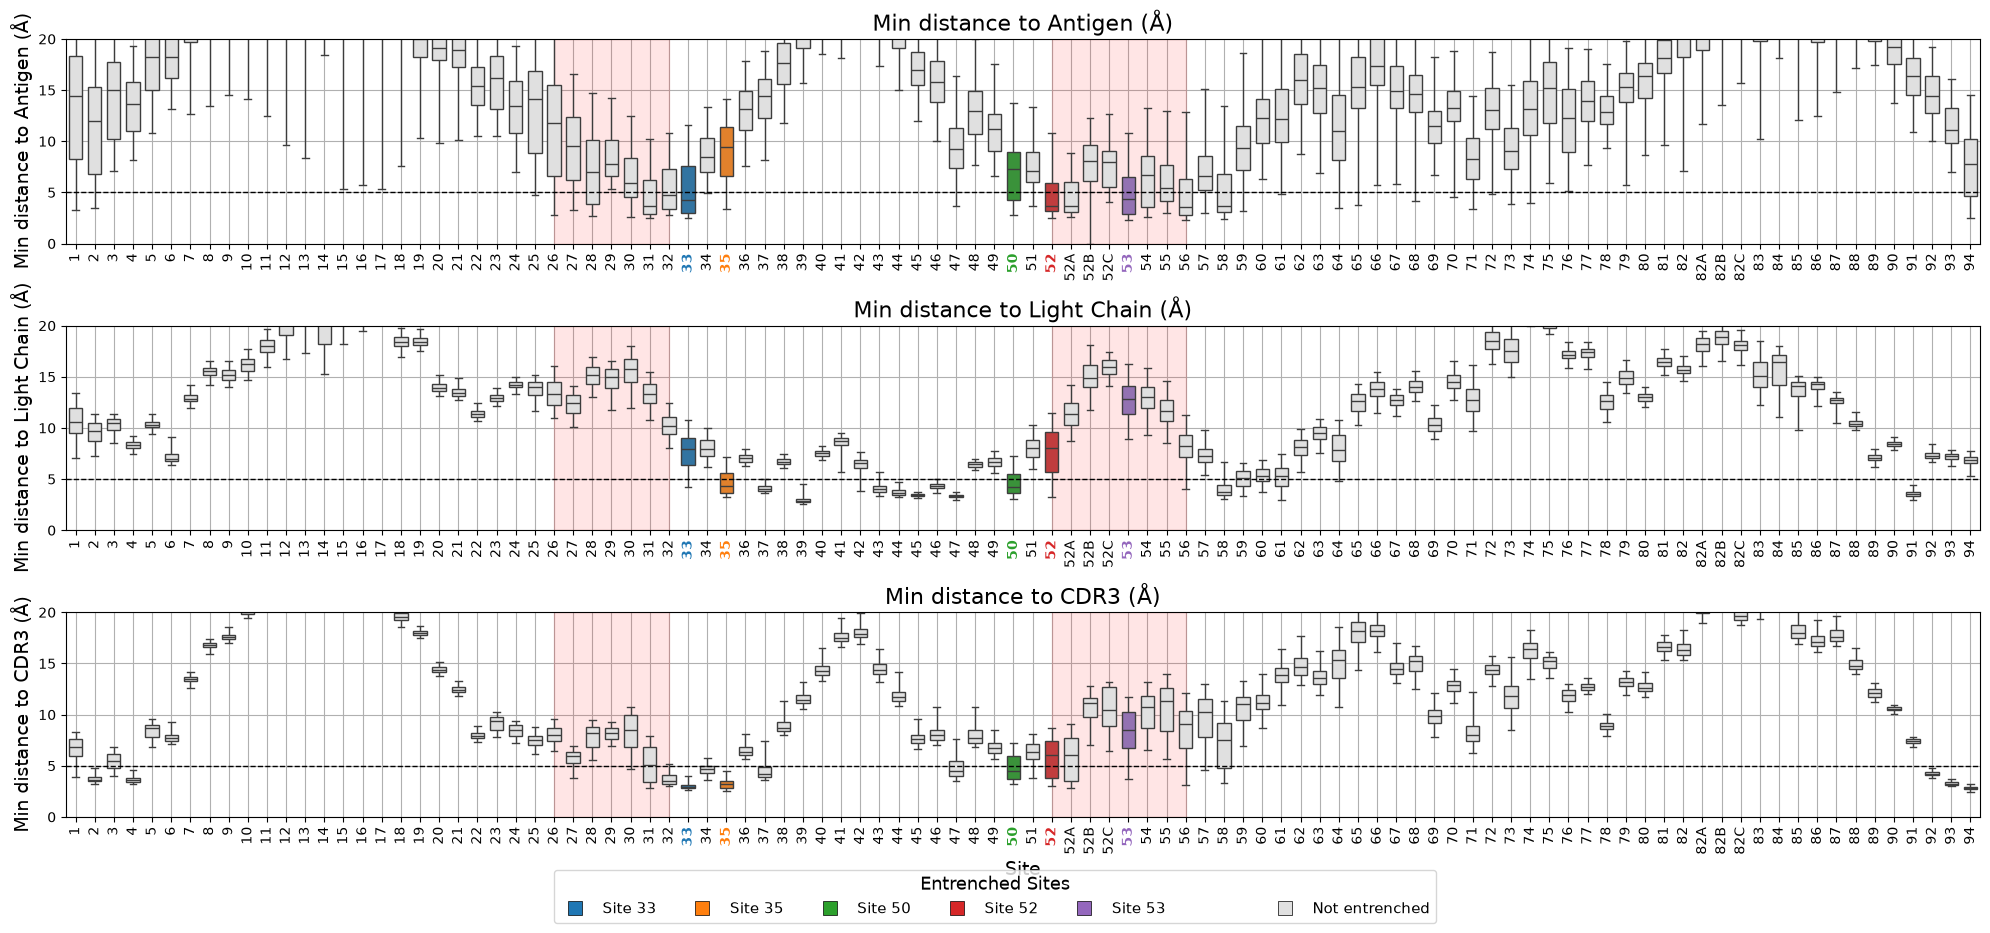

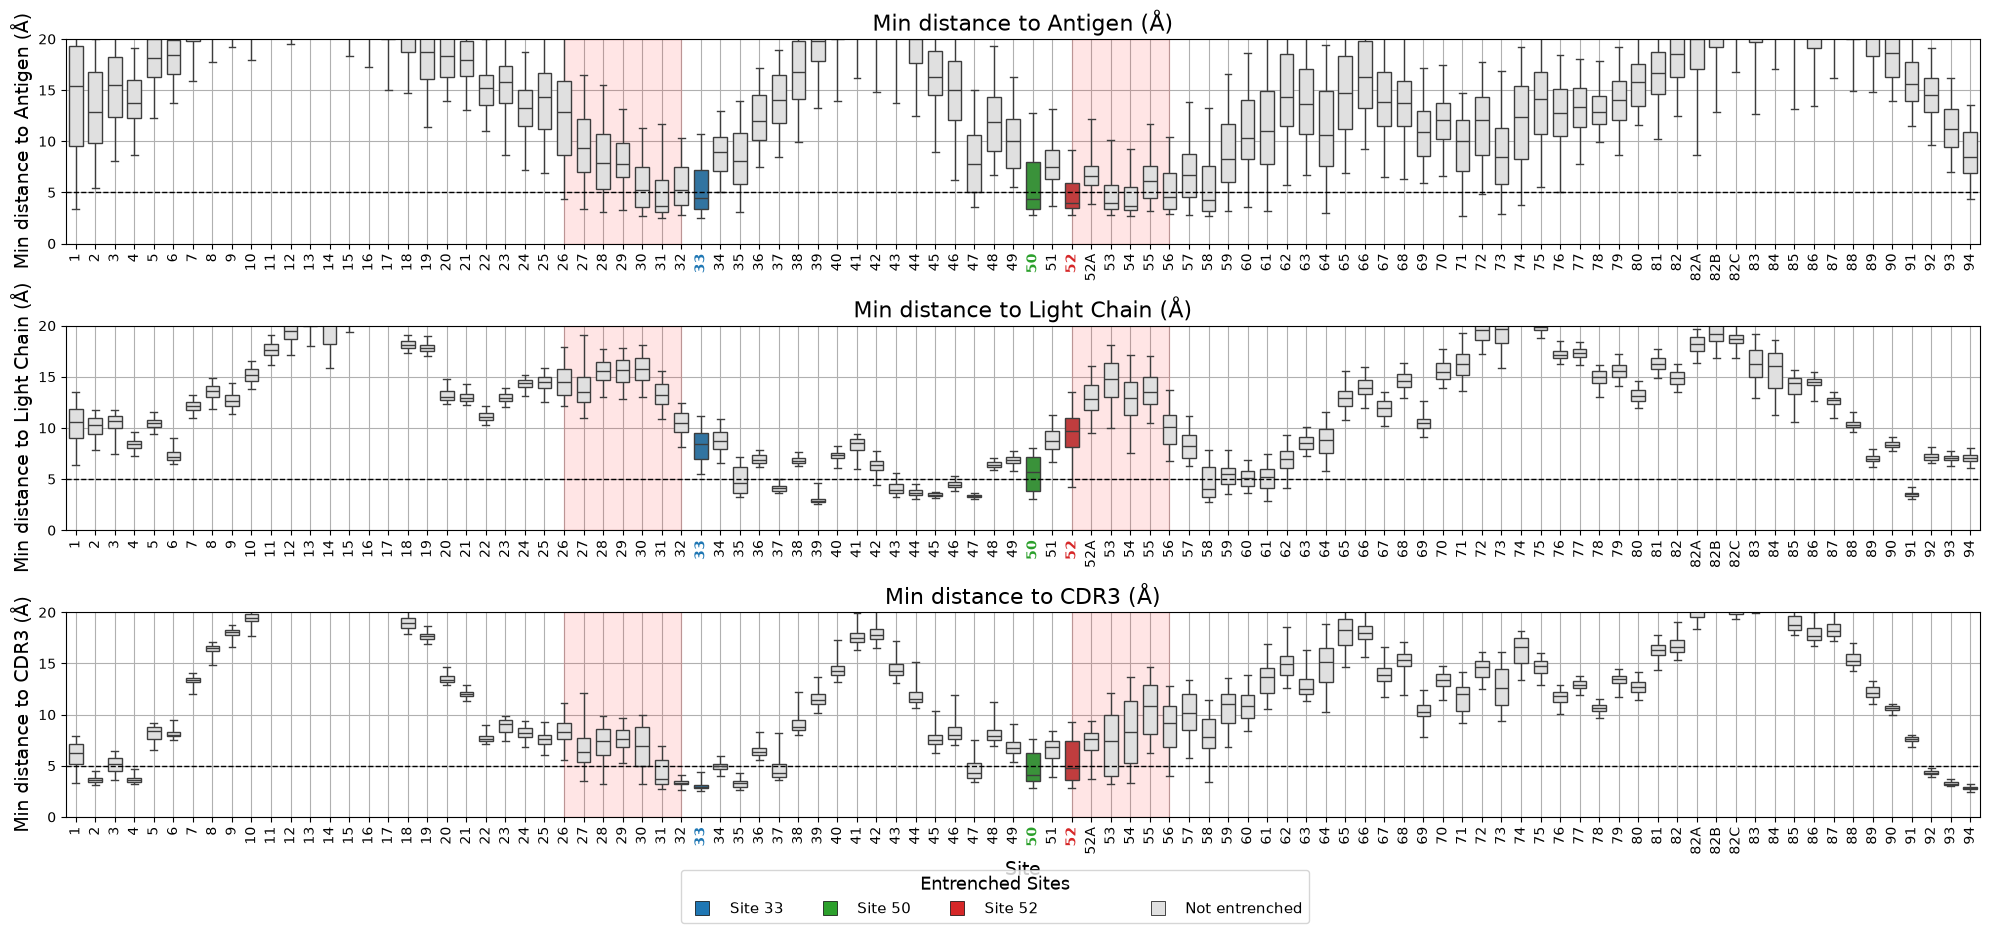

In [6]:
for vfam in ['IGHV3', 'IGHV1']:
    plot_contacts_by_entrenchment(
        df, vfam, entrenched[vfam], distance_metrics, ylim=(0, 20), ref_line=CONTACT_CUTOFF,
        save_path=f'figures/{vfam}_min_distance_by_entrenchment_within_vfamily.pdf',
    )

### Number of partner heavy atoms within 5 Å

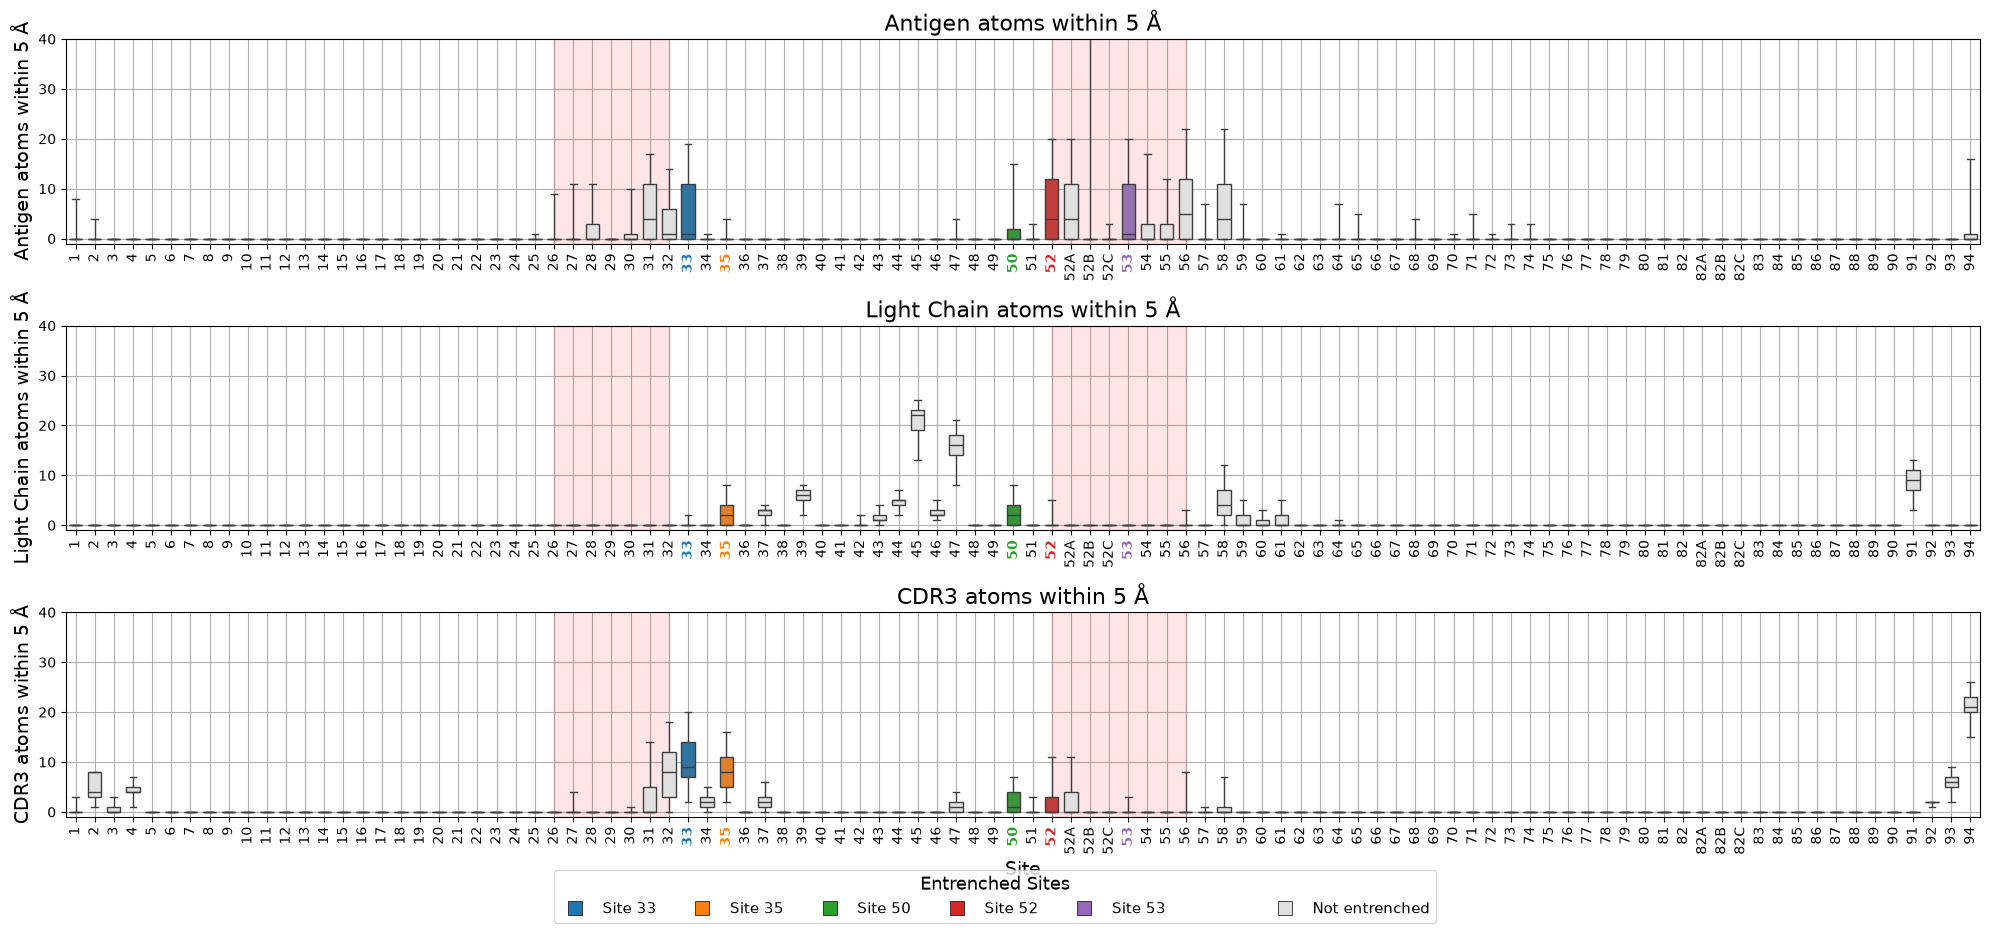

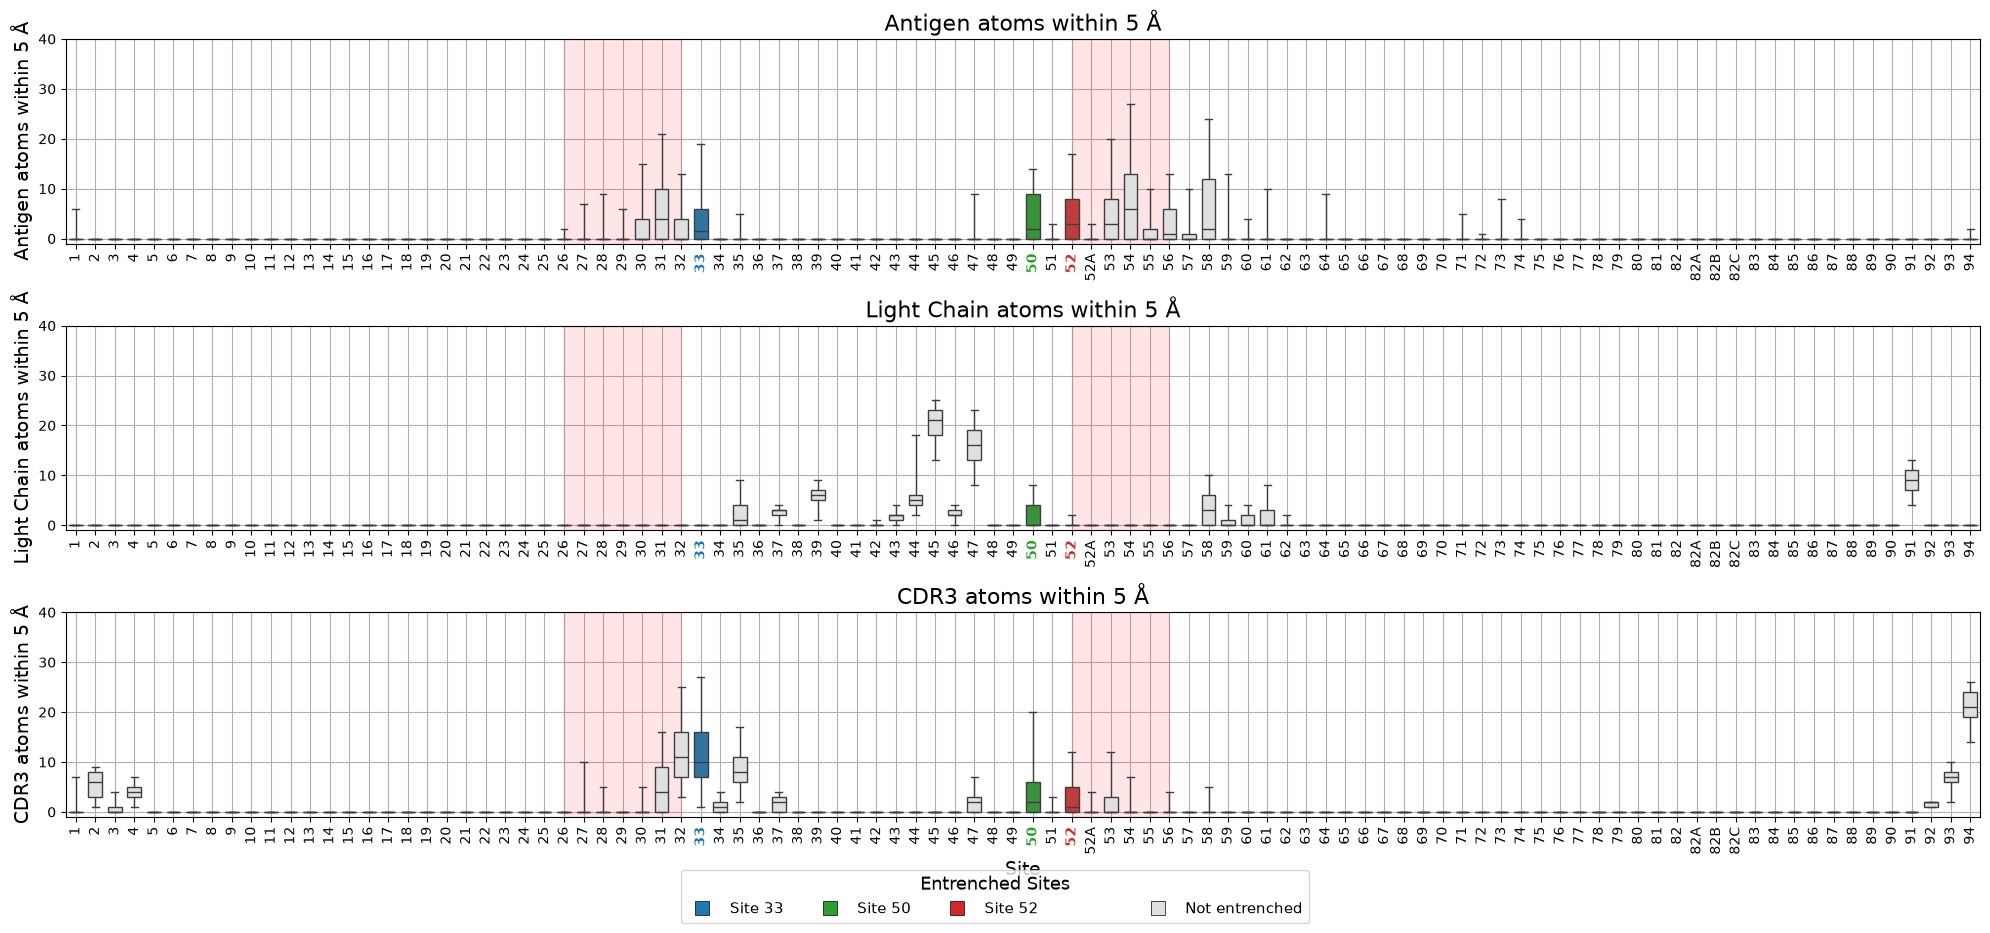

In [7]:
for vfam in ['IGHV3', 'IGHV1']:
    plot_contacts_by_entrenchment(
        df, vfam, entrenched[vfam], count_metrics, ylim=(-1, 40),
        save_path=f'figures/{vfam}_contacts_5A_by_entrenchment_within_vfamily.pdf',
    )

## Agreement between ΔRSA and distance-based contact

For each (family, site, partner) with at least `MIN_STRUCTURES` germline-encoded structures, we compare the fraction of structures in which the partner buries the site (ΔRSA > 0) with the fraction in which it lies within 5 Å, and the site medians of ΔRSA and of the 5 Å atom count.

In [8]:
rows = []
for (vfam, site), g in df_germ[df_germ.v_family_heavy.isin(['IGHV1', 'IGHV3'])].groupby(['v_family_heavy', 'site']):
    for partner, burial_col in PARTNERS.items():
        g_p = g.dropna(subset=[f'contact_{partner}'])
        if len(g_p) < MIN_STRUCTURES:
            continue
        rows.append({
            'v_family': vfam, 'site': site, 'partner': partner, 'n': len(g_p),
            'entrenched': site in entrenched[vfam],
            'frac_buried': g_p[f'buried_{partner}'].astype(float).mean(),
            'frac_contact_5A': g_p[f'contact_{partner}'].astype(float).mean(),
            'median_burial': g_p[burial_col].median(),
            'median_atoms_5A': g_p[f'n_atoms_5A_{partner}'].median(),
            'median_min_dist': g_p[f'min_dist_{partner}'].median(),
        })
site_summary = pd.DataFrame(rows)

corr = []
for (vfam, partner), g in site_summary.groupby(['v_family', 'partner']):
    corr.append({
        'v_family': vfam, 'partner': partner, 'n_sites': len(g),
        'spearman_frac': spearmanr(g.frac_buried, g.frac_contact_5A).statistic,
        'spearman_median': spearmanr(g.median_burial, g.median_atoms_5A).statistic,
    })
pd.DataFrame(corr).round(3)

,v_family,partner,n_sites,spearman_frac,spearman_median
0,IGHV1,antigen,98,0.898,0.947
1,IGHV1,cdr3,98,0.929,0.897
2,IGHV1,light,98,0.972,0.876
3,IGHV3,antigen,99,0.844,1.000
4,IGHV3,cdr3,99,0.988,0.838
5,IGHV3,light,99,0.948,0.885


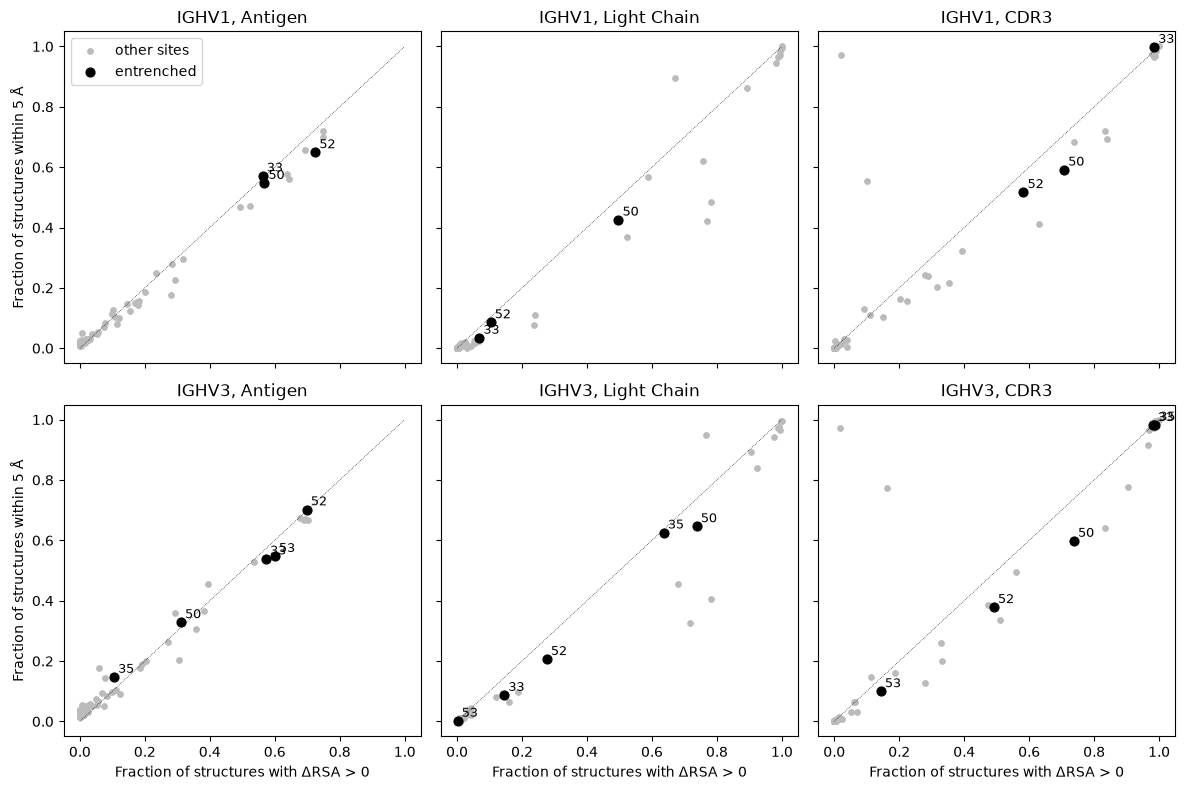

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
for i, vfam in enumerate(['IGHV1', 'IGHV3']):
    for j, partner in enumerate(PARTNERS):
        ax = axes[i, j]
        g = site_summary[(site_summary.v_family == vfam) & (site_summary.partner == partner)]
        ax.scatter(g.frac_buried, g.frac_contact_5A, s=15, color='#bbbbbb', label='other sites')
        e = g[g.entrenched]
        ax.scatter(e.frac_buried, e.frac_contact_5A, s=40, color='black', label='entrenched')
        for _, r in e.iterrows():
            ax.annotate(r.site, (r.frac_buried, r.frac_contact_5A), fontsize=9,
                        xytext=(3, 3), textcoords='offset points')
        ax.plot([0, 1], [0, 1], color='black', linewidth=0.5, linestyle=':')
        ax.set_title(f'{vfam}, {PARTNER_LABELS[partner]}')
        if i == 1:
            ax.set_xlabel('Fraction of structures with ΔRSA > 0')
        if j == 0:
            ax.set_ylabel('Fraction of structures within 5 Å')
axes[0, 0].legend()
plt.tight_layout()
fig.savefig('figures/contact_agreement_rsa_vs_distance.pdf', bbox_inches='tight')
plt.show()

### CDR-H3 contact sets

Sites the CDR-H3 contacts in more than half of a family's structures, under each definition.

In [11]:
for vfam in ['IGHV1', 'IGHV3']:
    g = site_summary[(site_summary.v_family == vfam) & (site_summary.partner == 'cdr3')]
    by_rsa = set(g[g.frac_buried > 0.5].site)
    by_dist = set(g[g.frac_contact_5A > 0.5].site)
    print(vfam)
    print('  both:          ', sort_antibody_sites(by_rsa & by_dist))
    print('  ΔRSA only:     ', sort_antibody_sites(by_rsa - by_dist))
    print('  distance only: ', sort_antibody_sites(by_dist - by_rsa))

IGHV1
  both:           ['2', '4', '31', '32', '33', '35', '37', '47', '50', '52', '93', '94']
  ΔRSA only:      ['3']
  distance only:  ['34', '92']
IGHV3
  both:           ['2', '4', '32', '33', '35', '37', '47', '50', '93', '94']
  ΔRSA only:      ['3', '31']
  distance only:  ['34', '92']


## Results

Distance-based contact reproduces the ΔRSA picture at within-family entrenched sites.

- Across sites with ≥30 germline-encoded structures, the fraction of structures in which a partner buries a site (ΔRSA > 0) and the fraction in which it lies within 5 Å are strongly correlated (Spearman 0.84–0.99 across the three partners in IGHV1 and IGHV3).
- The partner pattern at each entrenched site is unchanged (minimum-distance figures). In IGHV3, sites 33 and 52 are mainly contacted by antigen and CDR-H3, site 35 by CDR-H3 and the light chain, site 50 by all three, and site 53 mainly by antigen.
- Sites 31 and 32 lie within 5 Å of antigen and CDR-H3 in roughly half or more of the structures (minimum-distance figures), so partner contact is still not sufficient for entrenchment.
- The sets of sites the CDR-H3 contacts in more than half of the structures differ only at the margins: site 3 (and 31 in IGHV3) pass only under ΔRSA, and sites 34 and 92 only under the distance definition. Sites 34 and 92 are buried within the heavy chain, so a nearby CDR-H3 cannot reduce their already near-zero accessibility.
- Distance is systematically a little stricter than ΔRSA > 0 (points fall slightly below the diagonal), as expected because the 1.4 Å solvent probe lets partners slightly beyond 5 Å occlude surface.